# 单驼峰三维散点图

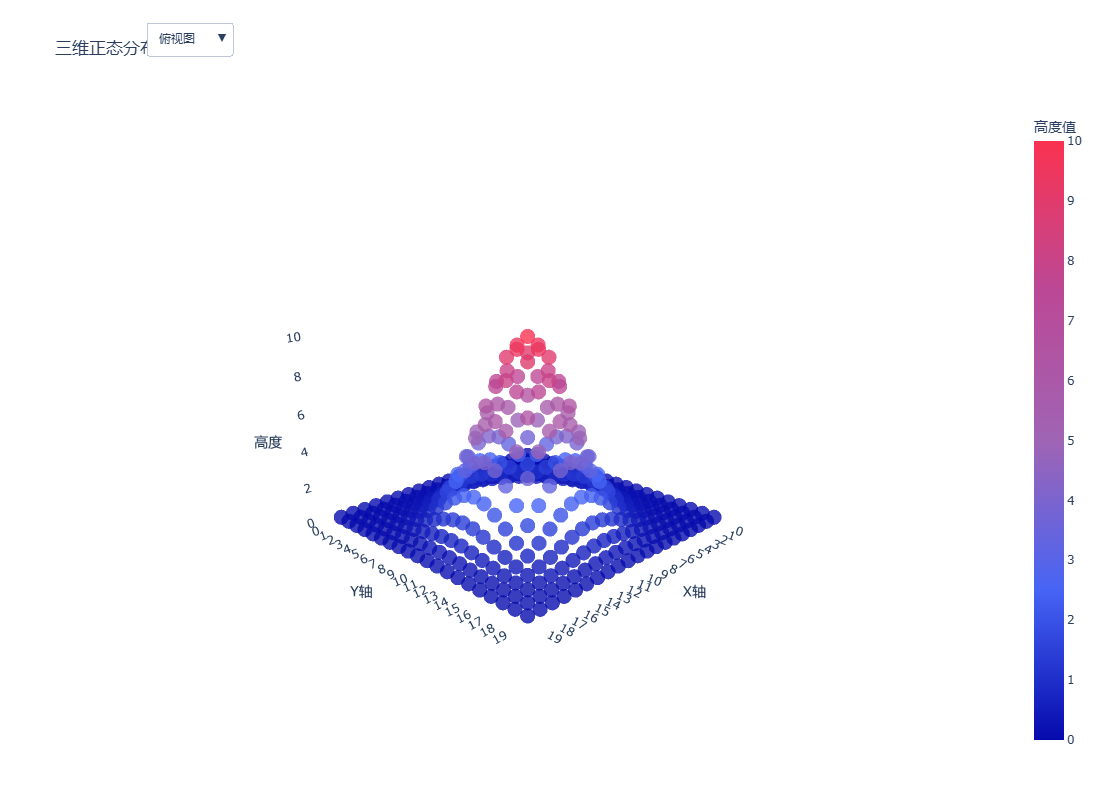

In [8]:
import plotly.graph_objects as go
import numpy as np

# 设置随机种子保证可重复性
np.random.seed(42)

# 创建网格数据 (20x20)
x_pos = np.arange(20)
y_pos = np.arange(20)
x, y = np.meshgrid(x_pos, y_pos)
x, y = x.flatten(), y.flatten()

# 生成正态分布形状的高度数据
def gaussian_2d(x, y, mx=10, my=10, sx=3, sy=3):
    return 10 * np.exp(-((x-mx)**2/(2*sx**2) + (y-my)**2/(2*sy**2)))

z = gaussian_2d(x, y)  # 应用正态分布函数

# 热力图配色方案 (从蓝到红)，有需要请自行调整
colorscale = [
    [0.0, 'rgb(5,10,172)'],
    [0.25, 'rgb(70,100,245)'],
    [0.5, 'rgb(159,100,180)'],
    [0.75, 'rgb(187,72,150)'],
    [1.0, 'rgb(250,50,80)']
]

# 创建3D散点图
fig = go.Figure(data=go.Scatter3d(
    x=x,
    y=y,
    z=z,
    mode='markers',
    marker=dict(
        size=8,  # 点的大小
        color=z,  # 颜色基于高度值
        colorscale=colorscale,
        opacity=0.8,
        colorbar=dict(title='高度值')
    ),
    text=[f"X: {xi}<br>Y: {yi}<br>Z: {zi:.2f}" for xi, yi, zi in zip(x, y, z)],  # 悬停文本
    hoverinfo='text'
))

# 设置布局
fig.update_layout(
    title='三维正态分布散点图',
    scene=dict(
        xaxis=dict(title='X轴', 
                   tickvals=x_pos,
                   showbackground=True,
                   backgroundcolor="rgba(240,240,240,0.9)"),
        yaxis=dict(title='Y轴', 
                   tickvals=y_pos,
                   showbackground=True,
                   backgroundcolor="rgba(240,240,240,0.9)"),
        zaxis=dict(title='高度',
                   showbackground=True,
                   backgroundcolor="rgba(240,240,240,0.9)"),
        camera=dict(
            eye=dict(x=1.8, y=1.8, z=0.8)  # 调整视角
        ),
        aspectratio=dict(x=1, y=1, z=0.7)  # 调整比例
    ),
    width=1000,
    height=800,
    margin=dict(l=50, r=50, b=50, t=50)
)

# 添加交互式按钮
fig.update_layout(
    updatemenus=[
        dict(
            buttons=list([
                dict(
                    label="俯视图",
                    method="update",
                    args=[{"scene.camera.eye": dict(x=0, y=0, z=2.5)}]
                ),
                dict(
                    label="45°视角",
                    method="update",
                    args=[{"scene.camera.eye": dict(x=1.8, y=1.8, z=0.8)}]
                ),
                dict(
                    label="侧视图",
                    method="update",
                    args=[{"scene.camera.eye": dict(x=0, y=2.5, z=0)}]
                )
            ]),
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.1,
            xanchor="left",
            y=1.15,
            yanchor="top"
        )
    ]
)

fig.show()

# 双驼峰三维散点图

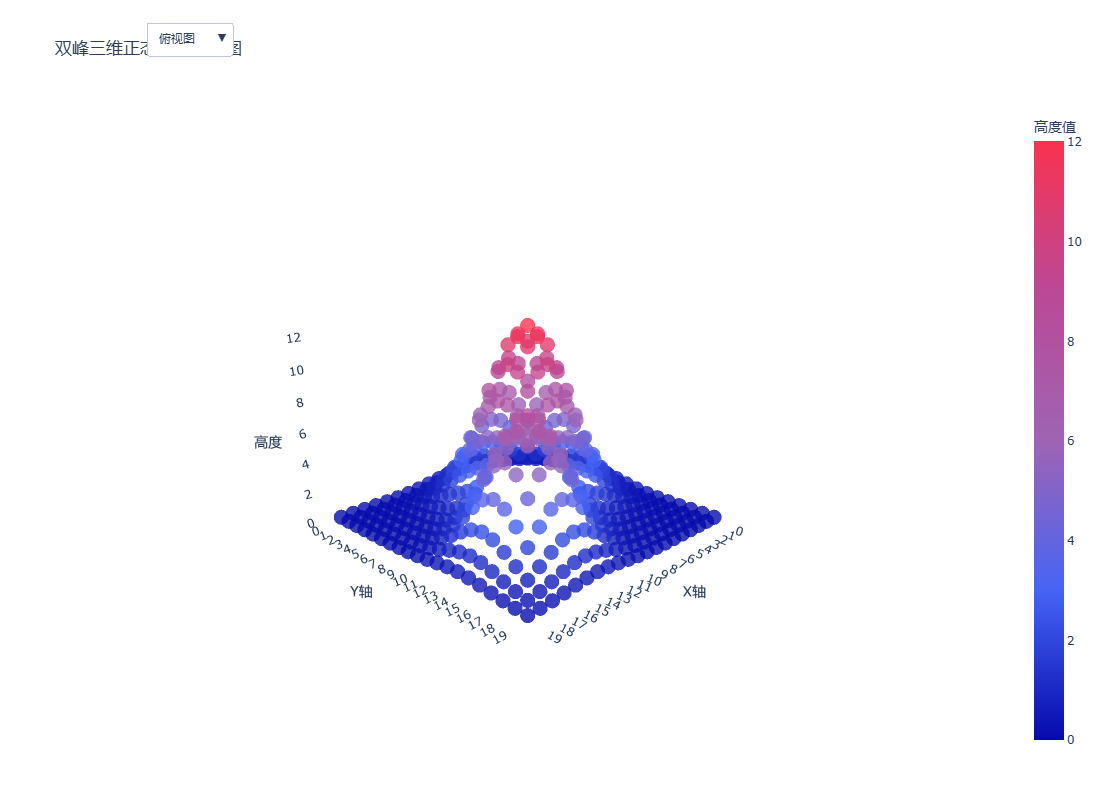

In [15]:
import plotly.graph_objects as go
import numpy as np

# 设置随机种子保证可重复性
np.random.seed(42)

# 创建网格数据 (20x20)
x_pos = np.arange(20)
y_pos = np.arange(20)
x, y = np.meshgrid(x_pos, y_pos)
x, y = x.flatten(), y.flatten()

# 生成双峰正态分布数据
def double_gaussian(x, y):
    # 第一个峰（较高）
    peak1 = 12 * np.exp(-((x-7)**2/(2*3**2) + (y-7)**2/(2*3**2)))
    # 第二个峰（较低）
    peak2 = 8 * np.exp(-((x-13)**2/(2*2.5**2) + (y-13)**2/(2*2.5**2)))
    return peak1 + peak2

z = double_gaussian(x, y)  # 应用双峰分布函数

# 热力图配色方案 (从蓝到红)
colorscale = [
    [0.0, 'rgb(5,10,172)'],
    [0.25, 'rgb(70,100,245)'],
    [0.5, 'rgb(159,100,180)'],
    [0.75, 'rgb(187,72,150)'],
    [1.0, 'rgb(250,50,80)']
]

# 创建3D散点图
fig = go.Figure(data=go.Scatter3d(
    x=x,
    y=y,
    z=z,
    mode='markers',
    marker=dict(
        size=8,  # 点的大小
        color=z,  # 颜色基于高度值
        colorscale=colorscale,
        opacity=0.8,
        colorbar=dict(title='高度值')
    ),
    text=[f"X: {xi}<br>Y: {yi}<br>Z: {zi:.2f}" for xi, yi, zi in zip(x, y, z)],  # 悬停文本
    hoverinfo='text'
))

# 设置布局
fig.update_layout(
    title='双峰三维正态分布散点图',
    scene=dict(
        xaxis=dict(title='X轴', 
                   tickvals=x_pos,
                   showbackground=True,
                   backgroundcolor="rgba(240,240,240,0.9)"),
        yaxis=dict(title='Y轴', 
                   tickvals=y_pos,
                   showbackground=True,
                   backgroundcolor="rgba(240,240,240,0.9)"),
        zaxis=dict(title='高度',
                   showbackground=True,
                   backgroundcolor="rgba(240,240,240,0.9)"),
        camera=dict(
            eye=dict(x=1.8, y=1.8, z=0.8)  # 调整视角
        ),
        aspectratio=dict(x=1, y=1, z=0.7)  # 调整比例
    ),
    width=1000,
    height=800,
    margin=dict(l=50, r=50, b=50, t=50)
)

# 添加交互式按钮
fig.update_layout(
    updatemenus=[
        dict(
            buttons=list([
                dict(
                    label="俯视图",
                    method="update",
                    args=[{"scene.camera.eye": dict(x=1, y=1, z=2.5)}]
                ),
                dict(
                    label="45°视角",
                    method="update",
                    args=[{"scene.camera.eye": dict(x=1.8, y=1.8, z=0.8)}]
                ),
                dict(
                    label="侧视图",
                    method="update",
                    args=[{"scene.camera.eye": dict(x=0, y=2.5, z=0)}]
                )
            ]),
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.1,
            xanchor="left",
            y=1.15,
            yanchor="top"
        )
    ]
)

fig.show()